In [4]:
import pandas as pd

In [5]:
import numpy as np
import matplotlib.pyplot as plt


In [6]:
import seaborn as sns

read in the data from local file

In [8]:
flood_data = pd.read_csv(r"C:\Users\PC\Downloads\ML\Asa_flood_modeling\Ilorin_Weather_1990_Present.csv")

In [9]:
### check the firt 10 rows of the data
flood_data.head(10)

,Date,Temperature_3PM_C,DewPoint_3PM_C,RH_3PM_%,Rain_fall,Run-off
0,01/01/1990,34.883875,7.955545,19.144153,0.0,0.000805
1,02/01/1990,34.783258,5.942545,16.764778,0.0,0.000834
2,03/01/1990,33.940118,12.950632,28.160457,0.0,0.000834
3,04/01/1990,34.124933,14.572626,30.972195,0.0,0.000805
4,05/01/1990,34.257715,14.929269,31.459893,0.0,0.001043
5,06/01/1990,32.962289,17.420755,39.645334,0.0,0.001609
6,07/01/1990,34.978159,15.626932,31.613974,0.0,0.000969
7,08/01/1990,35.230676,12.261591,25.057061,0.0,0.000924
8,09/01/1990,35.376428,8.328607,19.109364,0.0,0.000790
9,10/01/1990,35.243997,9.756677,21.198341,0.0,0.000805


Check for missing values and other inconsistencies

In [10]:
print(flood_data.info())
print(flood_data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12895 entries, 0 to 12894
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               12895 non-null  object 
 1   Temperature_3PM_C  12895 non-null  float64
 2   DewPoint_3PM_C     12895 non-null  float64
 3   RH_3PM_%           12895 non-null  float64
 4   Rain_fall          12843 non-null  float64
 5   Run-off            12895 non-null  float64
dtypes: float64(5), object(1)
memory usage: 604.6+ KB
None
Date                  0
Temperature_3PM_C     0
DewPoint_3PM_C        0
RH_3PM_%              0
Rain_fall            52
Run-off               0
dtype: int64


Rinfall contains 54 missing values so we used the mean value to fill the missing values

In [11]:
### format date_time column to datetime type
pd.to_datetime(flood_data['Date'], format="%d/%m/%Y", errors='coerce')


0       1990-01-01
1       1990-01-02
2       1990-01-03
3       1990-01-04
4       1990-01-05
           ...    
12890   2025-04-17
12891   2025-04-18
12892   2025-04-19
12893   2025-04-20
12894   2025-04-21
Name: Date, Length: 12895, dtype: datetime64[ns]

In [12]:
### handle missing values
flood_data['Rain_fall'].fillna(flood_data['Rain_fall'].mean(), inplace=True)

C:\Users\PC\AppData\Local\Temp\ipykernel_43360\1441383639.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  flood_data['Rain_fall'].fillna(flood_data['Rain_fall'].mean(), inplace=True)


In [130]:
### display descriptive statistics
flood_data.describe()

,Temperature_3PM_C,DewPoint_3PM_C,RH_3PM_%,Rain_fall,Run-off
count,12895.000000,12895.000000,12895.000000,12895.000000,12895.000000
mean,32.242982,16.645244,45.464387,3.238036,0.118183
std,3.843038,6.583764,22.347282,5.965083,1.148551
min,21.234064,-9.364706,4.245865,0.000000,0.000015
25%,29.145364,12.772211,24.607390,0.000000,0.000432
50%,32.678506,19.837503,46.545240,0.000000,0.001952
75%,35.395273,21.587572,63.542071,4.729825,0.016540
max,40.494974,25.510812,98.582113,62.897430,69.021761


The mean temperature was observed to bw 32.24982 while the highest temperature recorded within the specified period was 40.49 and the lowest was 21.23, all measured at degree centigrade.
For the rainfall, the mean recorded was 3.238036,the maximimum being 62.89734 and the standard deviation is 5.965083. This shows that the rain-fall measures are not well distributed around the mean.

In [13]:
### we craete a copy for training and testing
training_data = flood_data.copy()

In [18]:
### Extract the month from date column to study monthly trends
flood_data['Month'] = pd.to_datetime(flood_data['Date'], format="%d/%m/%Y", errors='coerce').dt.month

In [14]:
flood_data.head(5)

,Date,Temperature_3PM_C,DewPoint_3PM_C,RH_3PM_%,Rain_fall,Run-off
0,01/01/1990,34.883875,7.955545,19.144153,0.0,0.000805
1,02/01/1990,34.783258,5.942545,16.764778,0.0,0.000834
2,03/01/1990,33.940118,12.950632,28.160457,0.0,0.000834
3,04/01/1990,34.124933,14.572626,30.972195,0.0,0.000805
4,05/01/1990,34.257715,14.929269,31.459893,0.0,0.001043


In [19]:
#group by month and calculate total rainfall for each month

monthly_rainfall = flood_data.groupby('Month')['Rain_fall'].sum()
#assign month names for better readability
monthly_rainfall.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Find month with highest rainfall
max_rainfall_month = monthly_rainfall.idxmax()
max_rainfall_value = monthly_rainfall.max()
print(f"The month with the highest rainfall is {max_rainfall_month} with a total rainfall of {max_rainfall_value} mm.")



The month with the highest rainfall is Sep with a total rainfall of 9007.049315355 mm.


In [20]:
# Find month with highest rainfall
max_rainfall_month = monthly_rainfall.idxmax()
max_rainfall_value = monthly_rainfall.max()

In [136]:
print(f"The month with the highest rainfall is {max_rainfall_month} with a total rainfall of {max_rainfall_value} mm.")

The month with the highest rainfall is Sep with a total rainfall of 9007.049315355 mm.


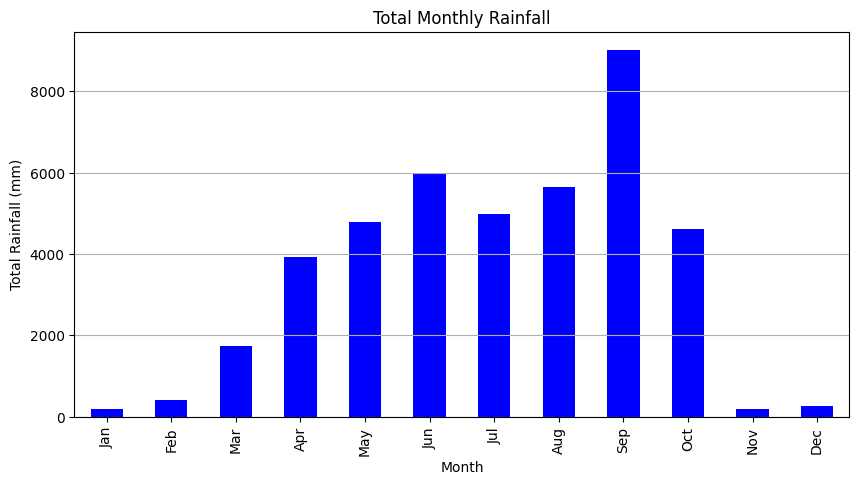

In [21]:
#plot the monthly rainfall
plt.figure(figsize=(10,5))
monthly_rainfall.plot(kind='bar',color='blue')
plt.title('Total Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.grid(axis='y')

In [22]:
#group by month and calculate total run_off for each month

monthly_runoff = flood_data.groupby('Month')['Run-off'].sum()
#assign month names for better readability
monthly_runoff.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Find month with highest rainfall
max_runoff_month = monthly_runoff.idxmax()
max_runoff_value = monthly_runoff.max()
print(f"The month with the highest runoff is {max_runoff_month} with a total rainfall of {max_runoff_value} mm.")


The month with the highest runoff is Sep with a total rainfall of 613.749504142 mm.


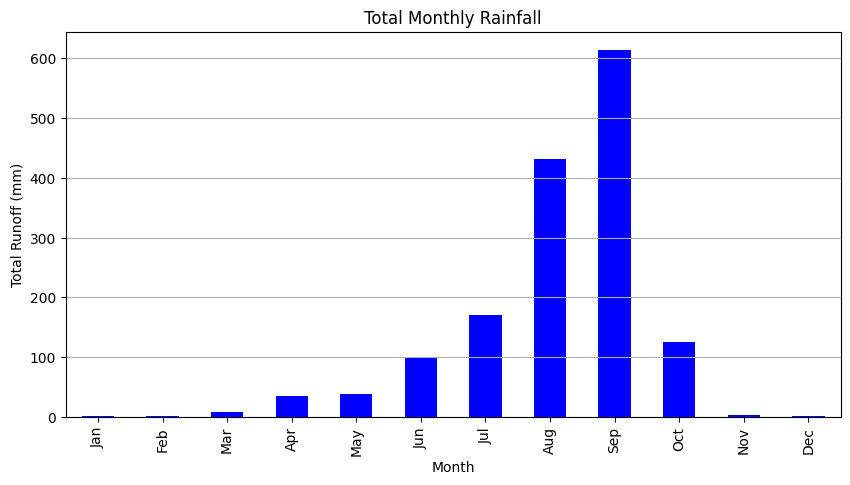

In [23]:
#plot the monthly runoff
plt.figure(figsize=(10,5))
monthly_runoff.plot(kind='bar',color='blue')
plt.title('Total Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Total Runoff (mm)')
plt.grid(axis='y')

In [24]:
##average monthly temperature
#group by month and calculate and find average temperature for each month

monthly_temp = flood_data.groupby('Month')['Temperature_3PM_C'].mean()
#assign month names for better readability
monthly_temp.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Find month with highest rainfall
max_monthly_temp_month = monthly_temp.idxmax()
max_monthly_value = monthly_temp.max()
print(f"The month with the highest temperature is {max_monthly_temp_month} with an average temperature of {max_monthly_value} degree.")


The month with the highest temperature is Mar with an average temperature of 36.79334676870968 degree.


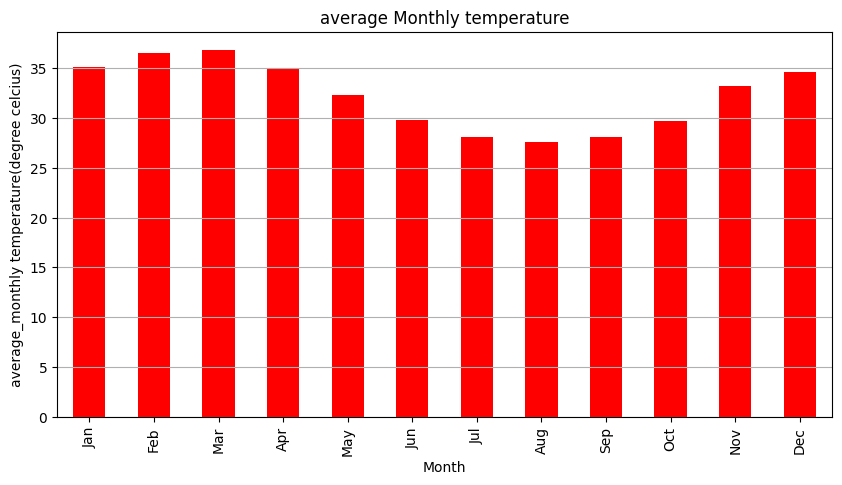

In [26]:
#plot the monthly runoff
plt.figure(figsize=(10,5))
monthly_temp.plot(kind='bar',color='red')
plt.title('average Monthly temperature')
plt.xlabel('Month')
plt.ylabel('average_monthly temperature(degree celcius)')
plt.grid(axis='y')

In [27]:
### climate change analysis and the last 20 years 
flood_data['Year'] = pd.to_datetime(flood_data['Date'], format="%d/%m/%Y", errors='coerce').dt.year
recent_20_years = flood_data[flood_data['Year'] >= 2004]
recent_20_years.head()

,Date,Temperature_3PM_C,DewPoint_3PM_C,RH_3PM_%,Rain_fall,Run-off,Month,Year
5113,01/01/2004,36.226038,8.032190,17.873809,0.0,0.000179,1,2004
5114,02/01/2004,35.357919,13.247675,26.543059,0.0,0.000194,1,2004
5115,03/01/2004,35.844080,13.023615,25.466793,0.0,0.000179,1,2004
5116,04/01/2004,36.896600,11.053186,21.113058,0.0,0.000179,1,2004
5117,05/01/2004,37.235590,9.974496,19.287407,0.0,0.000194,1,2004


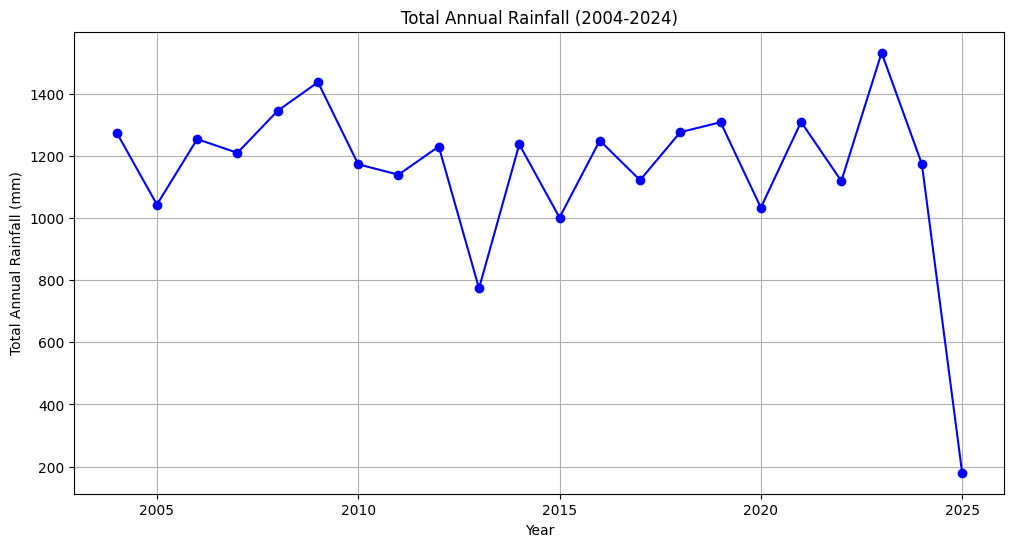

In [29]:
# plot monthly rainfall trends
plt.figure(figsize=(12,6))
recent_20_years.groupby('Year')['Rain_fall'].sum().plot(marker='o', color='blue')
plt.title('Total Annual Rainfall (2004-2024)')

plt.xlabel('Year')
plt.ylabel('Total Annual Rainfall (mm)')
plt.grid()
plt.show()

In [30]:
### year with highest rainfall
yearly_rainfall = recent_20_years.groupby('Year')['Rain_fall'].sum()
max_rainfall_year = yearly_rainfall.idxmax()
print(f"The year with the highest rainfall in the last 20 years is {max_rainfall_year} with a total rainfall of {yearly_rainfall[max_rainfall_year]} mm.")

The year with the highest rainfall in the last 20 years is 2023 with a total rainfall of 1531.855770283 mm.


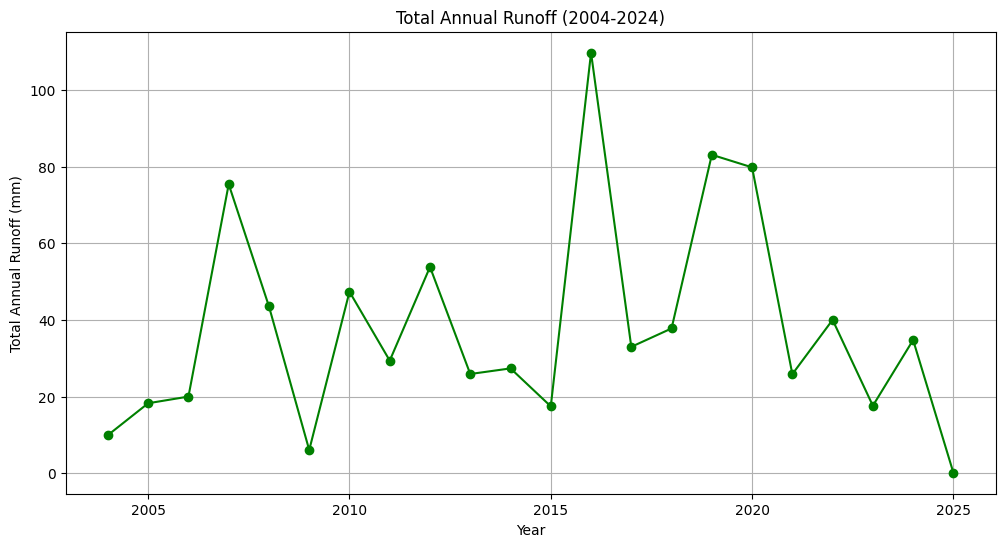

In [147]:
###plot yearly runoff trends 
plt.figure(figsize=(12,6))
recent_20_years.groupby('Year')['Run-off'].sum().plot(marker='o', color='green')
plt.title('Total Annual Runoff (2004-2024)')    
plt.xlabel('Year')
plt.ylabel('Total Annual Runoff (mm)')
plt.grid()
plt.show()


In [31]:
### year with highest runoff
yearly_runoff = recent_20_years.groupby('Year')['Run-off'].sum()
max_runoff_year = yearly_runoff.idxmax()
print(f"The year with the highest runoff in the last 20 years is {max_runoff_year} with a total runoff of {yearly_runoff[max_runoff_year]} mm.")

The year with the highest runoff in the last 20 years is 2016 with a total runoff of 109.805585816 mm.


                   Rain_fall   Run-off  ...  RH_3PM_%  DewPoint_3PM_C
Rain_fall           1.000000  0.108857  ...  0.451753        0.378796
Run-off             0.108857  1.000000  ...  0.173716        0.087017
Temperature_3PM_C  -0.395031 -0.179016  ... -0.918899       -0.662073
RH_3PM_%            0.451753  0.173716  ...  1.000000        0.878467
DewPoint_3PM_C      0.378796  0.087017  ...  0.878467        1.000000

[5 rows x 5 columns]


<Axes: >

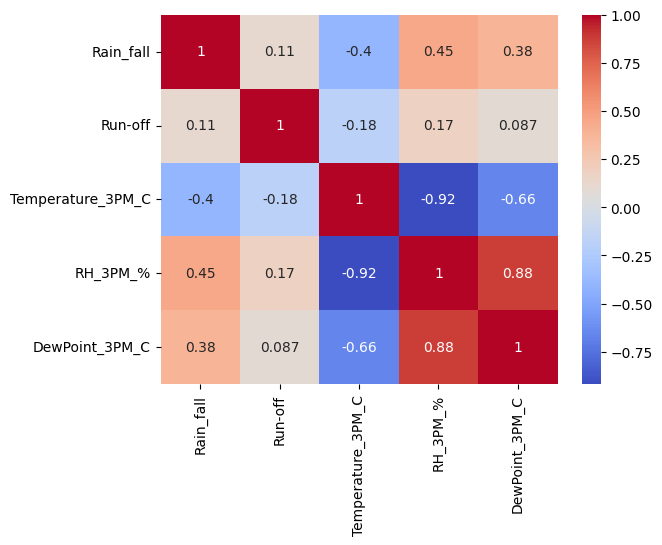

In [148]:
#correlation matrix
correlation_matrix = flood_data[['Rain_fall', 'Run-off', 'Temperature_3PM_C','RH_3PM_%','DewPoint_3PM_C']].corr()
print(correlation_matrix)
### visualize with heatmap
import seaborn as s
s.heatmap(correlation_matrix, annot=True, cmap='coolwarm')


In [32]:
#exponencially weighted average
alpha = 0.95  # Smoothing factor
flood_data['API_alpha'] = flood_data['Rain_fall'].ewm(alpha=alpha, adjust=False).mean()



In [34]:
monthly_cumulative_rainfall = flood_data.groupby('Month')['API_alpha'].sum()

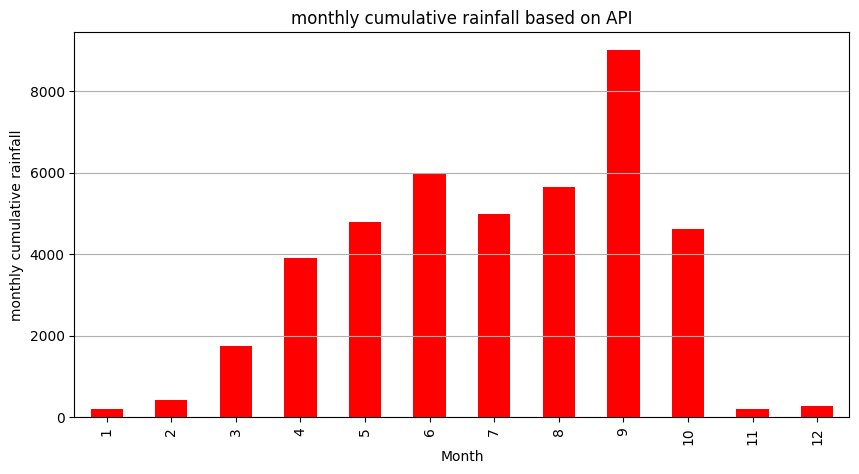

In [35]:
#plot the monthly runoff
plt.figure(figsize=(10,5))
monthly_cumulative_rainfall.plot(kind='bar',color='red')
plt.title('monthly cumulative rainfall based on API')
plt.xlabel('Month')
plt.ylabel('monthly cumulative rainfall')
plt.grid(axis='y')

In [36]:
#import necessary machines learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor  



In [37]:
### data splitting
training_data = flood_data.copy()

# Convert 'Date' column to datetime
training_data['Date'] = pd.to_datetime(training_data['Date'], format="%d/%m/%Y", errors='coerce')

training_data = training_data.sort_values(by='Date')

split_date = training_data['Date'].quantile(0.8)

###train_test split
train = training_data[training_data['Date'] <= split_date]
test = training_data[training_data['Date'] > split_date]
train.head()
test.head()

,Date,Temperature_3PM_C,DewPoint_3PM_C,RH_3PM_%,Rain_fall,Run-off,Month,Year,API_alpha
10316,2018-03-31,37.798822,15.293588,26.519762,0.00000,0.000134,3,2018,0.078683
10317,2018-04-01,38.310236,14.902505,25.155813,0.00000,0.000119,4,2018,0.003934
10318,2018-04-02,34.956796,16.976312,34.493310,0.00000,0.001043,4,2018,0.000197
10319,2018-04-03,37.697473,13.594781,23.891562,5.13497,0.000268,4,2018,4.878232
10320,2018-04-04,37.900247,15.473383,26.680689,0.00000,0.000343,4,2018,0.243912


In [39]:
### feature selection
x = train[['RH_3PM_%', 'API_alpha']]
y = train['Run-off']

In [40]:
### feature standardization
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
#convert scaled features back to DataFrame for better readability
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
#view the scaled features
x_scaled.head()




,RH_3PM_%,API_alpha
0,-1.207512,-0.56964
1,-1.314084,-0.56964
2,-0.803672,-0.56964
3,-0.677735,-0.56964
4,-0.655891,-0.56964


In [41]:
### model training with linear regression
lr_model = LinearRegression()   
lr_model.fit(x, y)
y_pred_lr = lr_model.predict(test[['RH_3PM_%', 'API_alpha']])

### print y_pred
print(y_pred_lr)


[-0.05732481 -0.06844591  0.00403055 ...  0.00547094  0.0061866
 -0.02153073]


In [159]:
#check model performance
mse_lr = mean_squared_error(test['Run-off'], y_pred_lr)
rmse= np.sqrt(mse_lr)
r2_lr = r2_score(test['Run-off'], y_pred_lr)
print(f"Linear Regression Model - MSE: {mse_lr}, RMSE: {rmse}, R²: {r2_lr}")

Linear Regression Model - MSE: 2.2223553806714658, RMSE: 1.4907566470324611, R²: 0.02390311244830856


In [160]:
# random forest regressor
rf_model = RandomForestRegressor(n_estimators=20, random_state=42)
rf_model.fit(x_scaled, y)
y_pred_rf = rf_model.predict(scaler.transform(test[['RH_3PM_%', 'API_alpha']])) 
#check model performance
mse_rf = mean_squared_error(test['Run-off'], y_pred_rf)
rmse_rf= np.sqrt(mse_rf)
r2_rf = r2_score(test['Run-off'], y_pred_rf)
print(f"Random Forest Model - MSE: {mse_rf}, RMSE: {rmse_rf}, R²: {r2_rf}")


Random Forest Model - MSE: 2.9613601813879162, RMSE: 1.7208603026939508, R²: -0.3006805667142647


c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [42]:
#xgboost regressor
xgbr = GradientBoostingRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42)
xgbr.fit(x, y)
y_pred_xgb = xgbr.predict(test[['RH_3PM_%', 'API_alpha']])
#check model performance
mse_xgb = mean_squared_error(test['Run-off'], y_pred_xgb)
rmse_xgb= np.sqrt(mse_xgb)
r2_xgb = r2_score(test['Run-off'], y_pred_xgb)
print(f"XGBoost Model - MSE: {mse_xgb}, RMSE: {rmse_xgb}, R²: {r2_xgb}")



XGBoost Model - MSE: 2.717654317739032, RMSE: 1.64853095747063, R²: -0.19364073993647035


In [51]:
import joblib
joblib.dump(xgbr, 'xgboost_model.joblib')

['xgboost_model.joblib']

In [162]:
%pip install statsmodels

### forecasting rainfall for the next 10 years using ARIMA model
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA   




     


Note: you may need to restart the kernel to use updated packages.


In [177]:



from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Convert the index to datetime (assuming a 'Date' column exists or the index is the date)
# If your DataFrame is indexed by date already, you can skip this.
# Example assumption: the date is in the index.

series=flood_data[['Date','Rain_fall']]
#series.index = pd.to_datetime(series.index)

# Select the rainfall series
#rainfall_series = series['Rain_fall'].asfreq('D') # Ensure daily frequency

# Check for missing values and fill them (e.g., with 0 or a daily mean, though 0 is common for rainfall)
series = series.fillna(0)
series.head()

# Plot the series to check for trends and seasonality
#plt.figure(figsize=(12, 6))
#rainfall_series.plot(title='Daily Rainfall Over 10 Years')
#plt.show()

# Decompose the series (optional, but helpful to see components)
# Note: Daily rainfall may not have a clear additive/multiplicative decomposition
# decomposition = seasonal_decompose(rainfall_series, model='additive', period=365) # Daily period
# decomposition.plot()
# plt.show()

,Date,Rain_fall
0,01/01/1990,0.0
1,02/01/1990,0.0
2,03/01/1990,0.0
3,04/01/1990,0.0
4,05/01/1990,0.0


In [ ]:
series.set_index('Date', inplace=True)
series.head()

,Rain_fall
Date,
01/01/1990,0.0
02/01/1990,0.0
03/01/1990,0.0
04/01/1990,0.0
05/01/1990,0.0


In [179]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series_new):
    result = adfuller(series_new.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    # If p-value > 0.05, the series is likely non-stationary.
    print(f'Is stationary (p < 0.05)? {"Yes" if result[1] < 0.05 else "No"}')

adf_test(series)

# If the series is NOT stationary (p-value > 0.05), you need to difference it.
# The number of times you difference it is the 'd' order.
# For daily rainfall, d is often 0 or 1.
# if adf_result_p_value > 0.05:
#     rainfall_diff = rainfall_series.diff().dropna()
#     adf_test(rainfall_diff)
#     d = 1
# else:
#     d = 0
d = 0 # Starting assumption

ADF Statistic: -11.390187976688402
p-value: 8.103806109605338e-21
Is stationary (p < 0.05)? Yes


In [180]:
# Define the ARIMA order
p = 5  # AR term
q = 5  # MA term
order = (p, d, q) # e.g., (5, 0, 5)

# 10 years of daily data is 3652 days. We'll use all of it for training.
train_data = series

print(f"Fitting ARIMA{order} on {len(train_data)} daily observations...")

# Note: This step can take a long time and may fail to converge for complex daily data.
try:
    model = ARIMA(train_data, order=order)
    model_fit = model.fit()

    print(model_fit.summary())

except Exception as e:
    print(f"Model fitting failed: {e}")
    # Consider adjusting p, d, q or using a Seasonal ARIMA (SARIMA)

Fitting ARIMA(5, 0, 5) on 12895 daily observations...


c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\stats

                               SARIMAX Results                                
Dep. Variable:              Rain_fall   No. Observations:                12895
Model:                 ARIMA(5, 0, 5)   Log Likelihood              -40245.867
Date:                Mon, 06 Oct 2025   AIC                          80515.734
Time:                        07:20:14   BIC                          80605.309
Sample:                             0   HQIC                         80545.676
                              - 12895                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2055      0.442      7.246      0.000       2.338       4.073
ar.L1          0.4566      0.502      0.910      0.363      -0.527       1.440
ar.L2          0.2150      0.652      0.330      0.7

Forecast generated for the next 10 years.


c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


<Figure size 1400x700 with 0 Axes>

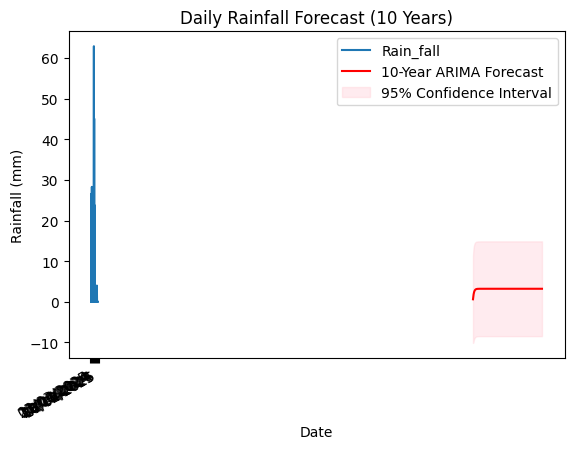

In [181]:
# Set the number of steps to forecast (10 years * ~365 days/year)
steps_to_forecast = 10 * 365

# Generate the forecast
# 'start' and 'end' can be used to specify the exact date range for the forecast
forecast_result = model_fit.get_forecast(steps=steps_to_forecast)

# Extract the predicted mean values and confidence intervals
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Ensure all forecasts are non-negative, which is critical for rainfall
forecast_mean[forecast_mean < 0] = 0

print("Forecast generated for the next 10 years.")

# Create a future index for plotting
last_date = series.index[-1]
future_dates = pd.date_range(start=last_date, periods=steps_to_forecast + 1, freq='D')[1:]

# Create a DataFrame for the final forecast
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Rainfall': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
}).set_index('Date')


# Plotting the results
plt.figure(figsize=(14, 7))
# Plot the last year of historical data
series.iloc[-365:].plot(label='Historical Rainfall (Last Year)')
# Plot the forecast
forecast_df['Forecasted_Rainfall'].plot(label='10-Year ARIMA Forecast', color='red')
# Plot confidence intervals
plt.fill_between(forecast_df.index,
                 forecast_df['Lower_CI'],
                 forecast_df['Upper_CI'], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Daily Rainfall Forecast (10 Years)')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

In [196]:
### climate change analysis for next 10 years

forecast_df['Year'] = forecast_df.index.year
next_10_years = forecast_df[forecast_df['Year'] >= 2025]
next_10_years.head()

,Forecasted_Rainfall,Lower_CI,Upper_CI,API_alpha,Year
Date,,,,,
2025-04-22,0.614370,-10.129446,11.358186,0.614370,2025
2025-04-23,0.659571,-10.113434,11.432577,0.657311,2025
2025-04-24,0.667643,-10.106313,11.441600,0.667127,2025
2025-04-25,0.722628,-10.094308,11.539564,0.719853,2025
2025-04-26,0.783561,-10.085904,11.653026,0.780376,2025


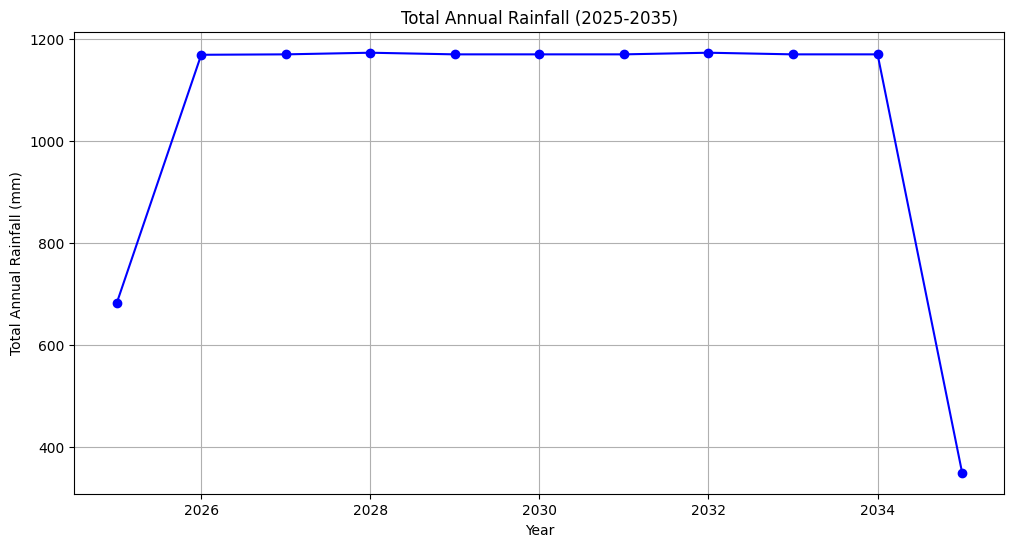

In [199]:
# plot monthly rainfall trends
plt.figure(figsize=(12,6))
next_10_years.groupby('Year')['API_alpha'].sum().plot(marker='o', color='blue')
plt.title('Total Annual Rainfall (2025-2035)')

plt.xlabel('Year')
plt.ylabel('Total Annual Rainfall (mm)')
plt.grid()
plt.show()

In [182]:
forecast_df.head(10)

,Forecasted_Rainfall,Lower_CI,Upper_CI
Date,,,
2025-04-22,0.614370,-10.129446,11.358186
2025-04-23,0.659571,-10.113434,11.432577
2025-04-24,0.667643,-10.106313,11.441600
2025-04-25,0.722628,-10.094308,11.539564
2025-04-26,0.783561,-10.085904,11.653026
2025-04-27,0.821576,-10.068306,11.711459
2025-04-28,0.861099,-10.050801,11.772999
2025-04-29,0.915806,-10.038093,11.869706
2025-04-30,0.961469,-10.021616,11.944553


In [186]:
#exponencially weighted average
alpha = 0.95  # Smoothing factor
forecast_df['API_alpha'] = forecast_df['Forecasted_Rainfall'].ewm(alpha=alpha, adjust=False).mean()
forecast_df.head(-10)



,Forecasted_Rainfall,Lower_CI,Upper_CI,API_alpha
Date,,,,
2025-04-22,0.614370,-10.129446,11.358186,0.614370
2025-04-23,0.659571,-10.113434,11.432577,0.657311
2025-04-24,0.667643,-10.106313,11.441600,0.667127
2025-04-25,0.722628,-10.094308,11.539564,0.719853
2025-04-26,0.783561,-10.085904,11.653026,0.780376
...,...,...,...,...
2035-04-05,3.205507,-8.458749,14.869763,3.205507
2035-04-06,3.205507,-8.458749,14.869763,3.205507
2035-04-07,3.205507,-8.458749,14.869763,3.205507


In [188]:

series_RH = flood_data[['Date','RH_3PM_%']]

series_RH.set_index('Date', inplace=True)
series_RH.head()

,RH_3PM_%
Date,
01/01/1990,19.144153
02/01/1990,16.764778
03/01/1990,28.160457
04/01/1990,30.972195
05/01/1990,31.459893


In [189]:
# Define the ARIMA order
p = 5  # AR term
q = 5  # MA term
order = (p, d, q) # e.g., (5, 0, 5)

# 10 years of daily data is 3652 days. We'll use all of it for training.
train_data_RH = series_RH

print(f"Fitting ARIMA{order} on {len(train_data_RH)} daily observations...")

# Note: This step can take a long time and may fail to converge for complex daily data.
try:
    model = ARIMA(train_data_RH, order=order)
    model_fit = model.fit()

    print(model_fit.summary())

except Exception as e:
    print(f"Model fitting failed: {e}")
    # Consider adjusting p, d, q or using a Seasonal ARIMA (SARIMA)

Fitting ARIMA(5, 0, 5) on 12895 daily observations...


c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\stats

                               SARIMAX Results                                
Dep. Variable:               RH_3PM_%   No. Observations:                12895
Model:                 ARIMA(5, 0, 5)   Log Likelihood              -46816.272
Date:                Tue, 07 Oct 2025   AIC                          93656.545
Time:                        20:29:31   BIC                          93746.120
Sample:                             0   HQIC                         93686.486
                              - 12895                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.4579      3.825     11.884      0.000      37.961      52.955
ar.L1          1.0231      1.511      0.677      0.498      -1.938       3.984
ar.L2         -0.6136      1.028     -0.597      0.5

Forecast generated for the next 10 years.


c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\PC\Downloads\ML\Asa_flood_modeling\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


<Figure size 1400x700 with 0 Axes>

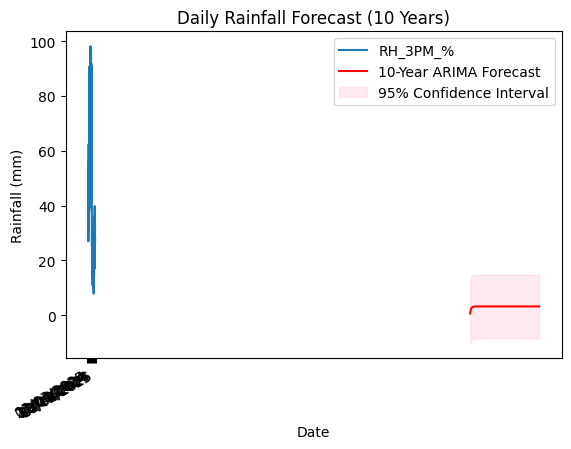

In [190]:
# Set the number of steps to forecast (10 years * ~365 days/year)
steps_to_forecast = 10 * 365

# Generate the forecast
# 'start' and 'end' can be used to specify the exact date range for the forecast
forecast_result_RH = model_fit.get_forecast(steps=steps_to_forecast)

# Extract the predicted mean values and confidence intervals
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Ensure all forecasts are non-negative, which is critical for rainfall
forecast_mean[forecast_mean < 0] = 0

print("Forecast generated for the next 10 years.")

# Create a future index for plotting
last_date = series_RH.index[-1]
future_dates = pd.date_range(start=last_date, periods=steps_to_forecast + 1, freq='D')[1:]

# Create a DataFrame for the final forecast
forecast_RH_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_RH': forecast_mean.values,
    'Lower_CI': forecast_ci.iloc[:, 0].values,
    'Upper_CI': forecast_ci.iloc[:, 1].values
}).set_index('Date')


# Plotting the results
plt.figure(figsize=(14, 7))
# Plot the last year of historical data
series_RH.iloc[-365:].plot(label='Historical Rainfall (Last Year)')
# Plot the forecast
forecast_df['Forecasted_Rainfall'].plot(label='10-Year ARIMA Forecast', color='red')
# Plot confidence intervals
plt.fill_between(forecast_RH_df.index,
                 forecast_RH_df['Lower_CI'],
                 forecast_RH_df['Upper_CI'], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Daily Rainfall Forecast (10 Years)')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

In [191]:
forecast_RH_df.head(10)

,Forecasted_RH,Lower_CI,Upper_CI
Date,,,
2025-04-22,0.614370,-10.129446,11.358186
2025-04-23,0.659571,-10.113434,11.432577
2025-04-24,0.667643,-10.106313,11.441600
2025-04-25,0.722628,-10.094308,11.539564
2025-04-26,0.783561,-10.085904,11.653026
2025-04-27,0.821576,-10.068306,11.711459
2025-04-28,0.861099,-10.050801,11.772999
2025-04-29,0.915806,-10.038093,11.869706
2025-04-30,0.961469,-10.021616,11.944553


In [192]:
#merge the two forecast dataframes
final_forecast = pd.merge(forecast_df, forecast_RH_df, left_index=True, right_index=True)
final_forecast.head(10)

,Forecasted_Rainfall,Lower_CI_x,Upper_CI_x,API_alpha,Forecasted_RH,Lower_CI_y,Upper_CI_y
Date,,,,,,,
2025-04-22,0.614370,-10.129446,11.358186,0.614370,0.614370,-10.129446,11.358186
2025-04-23,0.659571,-10.113434,11.432577,0.657311,0.659571,-10.113434,11.432577
2025-04-24,0.667643,-10.106313,11.441600,0.667127,0.667643,-10.106313,11.441600
2025-04-25,0.722628,-10.094308,11.539564,0.719853,0.722628,-10.094308,11.539564
2025-04-26,0.783561,-10.085904,11.653026,0.780376,0.783561,-10.085904,11.653026
2025-04-27,0.821576,-10.068306,11.711459,0.819516,0.821576,-10.068306,11.711459
2025-04-28,0.861099,-10.050801,11.772999,0.859020,0.861099,-10.050801,11.772999
2025-04-29,0.915806,-10.038093,11.869706,0.912967,0.915806,-10.038093,11.869706
2025-04-30,0.961469,-10.021616,11.944553,0.959044,0.961469,-10.021616,11.944553


In [194]:
### feature selection
x_forecast = final_forecast[['Forecasted_RH', 'API_alpha']]

x_forecast.head(10)

,Forecasted_RH,API_alpha
Date,,
2025-04-22,0.614370,0.614370
2025-04-23,0.659571,0.657311
2025-04-24,0.667643,0.667127
2025-04-25,0.722628,0.719853
2025-04-26,0.783561,0.780376
2025-04-27,0.821576,0.819516
2025-04-28,0.861099,0.859020
2025-04-29,0.915806,0.912967
2025-04-30,0.961469,0.959044


In [207]:


forecast_training = x_forecast.sort_index()

# Convert DatetimeIndex to int64 for quantile calculation
split_date_int = np.quantile(forecast_training.index.astype(np.int64), 0.8)
split_date = pd.to_datetime(split_date_int)

###train_test split
train_x = forecast_training[forecast_training.index <= split_date]
test_x = forecast_training[forecast_training.index > split_date]
train_x.head()
test_x.head()

,Forecasted_RH,API_alpha
Date,,
2033-04-20,3.205507,3.205507
2033-04-21,3.205507,3.205507
2033-04-22,3.205507,3.205507
2033-04-23,3.205507,3.205507
2033-04-24,3.205507,3.205507


In [210]:
### feature selection
x = train_x[['Forecasted_RH', 'API_alpha']]
y = test['Run-off']

In [211]:
#xgboost regressor
xgbr = GradientBoostingRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42)
xgbr.fit(x, y)
y_pred_xgb = xgbr.predict(test[['Forecasted_RH', 'API_alpha']])
#check model performance
mse_xgb = mean_squared_error(test['Run-off'], y_pred_xgb)
rmse_xgb= np.sqrt(mse_xgb)
r2_xgb = r2_score(test['Run-off'], y_pred_xgb)
print(f"XGBoost Model - MSE: {mse_xgb}, RMSE: {rmse_xgb}, R²: {r2_xgb}")

ValueError: Found input variables with inconsistent numbers of samples: [2920, 2579]